In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import gaussian
from PIL import Image
from skimage.util import random_noise


In [ ]:
imagem = "/content/joana.jpg"
img = Image.open(imagem).convert("L")
img_np = np.array(img, dtype=np.float32)

In [ ]:
mean=0
var = 1000
sigma = var**0.5

gaussian_noise = np.random.normal(mean, sigma, img_np.shape)

In [ ]:
noisy_image = img_np + gaussian_noise

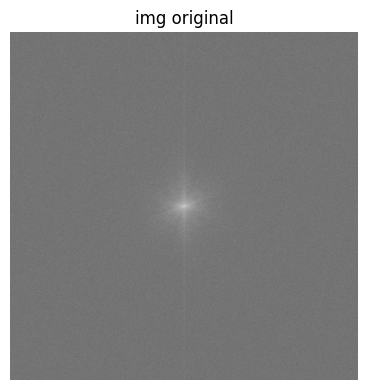

In [ ]:
F = np.fft.fft2(noisy_image)
F_shift = np.fft.fftshift(F)
magnitude = np.log1p(np.abs(F_shift))

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(magnitude, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image, ImageDraw
import random

WIDTH, HEIGHT = 200, 200

# ⚫⚪ 1. Listras horizontais (preto e branco)
def listras_horizontais_pb():
    img = Image.new("1", (WIDTH, HEIGHT), 1)  # 1 = branco
    draw = ImageDraw.Draw(img)

    y = 0
    cor = 0  # começa preto

    while y < HEIGHT:
        altura = random.randint(10, 100)
        draw.rectangle([0, y, WIDTH, y + altura], fill=cor)
        cor = 1 - cor  # alterna preto/branco
        y += altura

    img.save("listras_horizontais_pb.png")


# ⚫⚪ 2. Listras verticais (preto e branco)
def listras_verticais_pb():
    img = Image.new("1", (WIDTH, HEIGHT), 1)
    draw = ImageDraw.Draw(img)

    x = 0
    cor = 0

    while x < WIDTH:
        largura = random.randint(10, 100)
        draw.rectangle([x, 0, x + largura, HEIGHT], fill=cor)
        cor = 1 - cor
        x += largura

    img.save("listras_verticais_pb.png")


# ⚫⚪ 3. Quadriculado simples (preto e branco aleatório)
def quadriculado_pb():
    img = Image.new("1", (WIDTH, HEIGHT), 1)
    draw = ImageDraw.Draw(img)

    linhas = random.randint(5, 20)
    colunas = random.randint(5, 20)

    cell_w = WIDTH // colunas
    cell_h = HEIGHT // linhas

    for i in range(linhas):
        for j in range(colunas):
            cor = random.choice([0, 1])
            draw.rectangle(
                [j * cell_w, i * cell_h, (j + 1) * cell_w, (i + 1) * cell_h],
                fill=cor
            )

    img.save("quadriculado_pb.png")


# ♟️ 4. Tabuleiro de xadrez (configurável)
def tabuleiro_xadrez(n=8):
    """
    n = número de quadrados por lado (ex: 8 = xadrez clássico)
    """
    img = Image.new("1", (WIDTH, HEIGHT), 1)
    draw = ImageDraw.Draw(img)

    cell_w = WIDTH // n
    cell_h = HEIGHT // n

    for i in range(n):
        for j in range(n):
            # alternância padrão de xadrez
            cor = (i + j) % 2
            draw.rectangle(
                [j * cell_w, i * cell_h, (j + 1) * cell_w, (i + 1) * cell_h],
                fill=cor
            )

    img.save(f"tabuleiro_{n}x{n}.png")


# ⚫⚪ 5. Esferas (preto e branco)
def esferas_pb():
    img = Image.new("1", (WIDTH, HEIGHT), 1)
    draw = ImageDraw.Draw(img)

    quantidade = random.randint(10, 50)

    for _ in range(quantidade):
        raio = random.randint(10, 80)
        x = random.randint(0, WIDTH)
        y = random.randint(0, HEIGHT)

        cor = random.choice([0, 1])

        draw.ellipse(
            [x - raio, y - raio, x + raio, y + raio],
            fill=cor
        )

    img.save("esferas_pb.png")


# 🚀 Executar
listras_horizontais_pb()
listras_verticais_pb()
quadriculado_pb()
tabuleiro_xadrez(8)   # mude aqui (ex: 4, 10, 20...)
esferas_pb()

print("Imagens preto e branco geradas!")

Imagens preto e branco geradas!


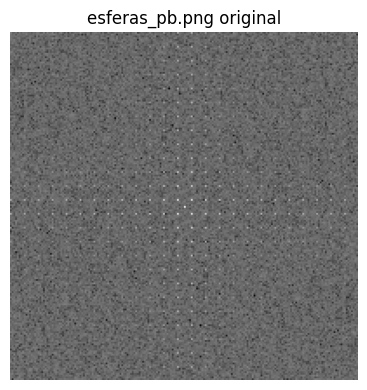

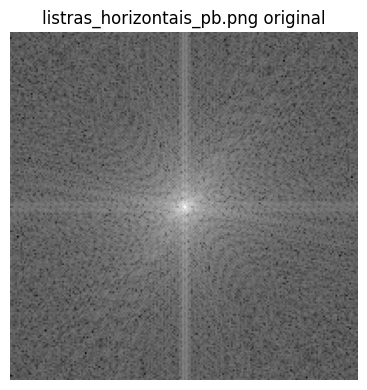

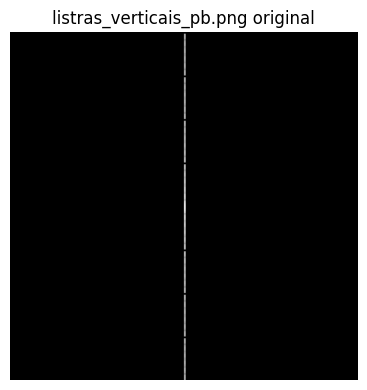

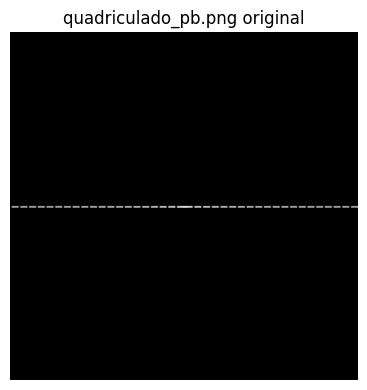

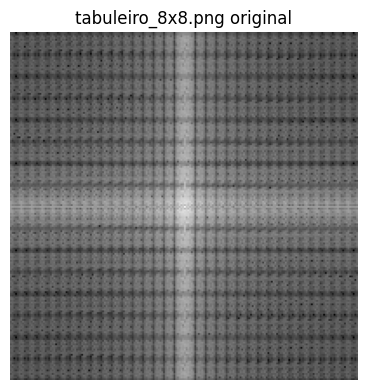

In [ ]:
lista_imagens = ['esferas_pb.png', 'listras_horizontais_pb.png','listras_verticais_pb.png', 'quadriculado_pb.png', 'tabuleiro_8x8.png']
for i in lista_imagens:
  imagem = i
  img = Image.open(imagem).convert("L")
  img_np = np.array(img, dtype=np.float32)
  mean=0
  var = 0
  sigma = var**0.5

  gaussian_noise = np.random.normal(mean, sigma, img_np.shape)

  F = np.fft.fft2(noisy_image)
  F_shift = np.fft.fftshift(F)
  magnitude = np.log1p(np.abs(F_shift))

  noisy_image = img_np + gaussian_noise

  plt.figure(figsize=(10, 4))
  plt.subplot(1,2,1)
  plt.title(f'{i} original')
  plt.imshow(magnitude, cmap='gray')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

# imagem mais homogenia


# 🧠 Interpretação de Imagens no Domínio da Frequência

A Transformada de Fourier permite representar uma imagem no domínio da frequência, onde cada ponto do espectro indica a intensidade de uma determinada frequência espacial presente na imagem.

## 🔍 Conceito geral

* **Frequências baixas (centro da imagem):**
  Representam variações suaves de intensidade, como iluminação e formas grandes.

* **Frequências altas (bordas da imagem):**
  Representam mudanças bruscas, como bordas, detalhes finos e ruído.

Após aplicar o `fftshift`, as baixas frequências ficam concentradas no centro do espectro, facilitando a análise.

---

## 📊 Como interpretar o espectro

### 🔵 Região central (baixas frequências)

* Alta intensidade → imagem mais suave (poucos detalhes)
* Baixa intensidade → imagem com menos regiões uniformes

### 🔴 Regiões periféricas (altas frequências)

* Alta intensidade → presença de detalhes ou ruído
* Baixa intensidade → imagem mais limpa e menos detalhada

---

## 📐 Interpretação de padrões

### ✔ Listras verticais

* FFT apresenta pontos no eixo horizontal
* Indica variação na direção horizontal

### ✔ Listras horizontais

* FFT apresenta pontos no eixo vertical
* Indica variação na direção vertical

### ✔ Padrão quadriculado (xadrez)

* FFT apresenta múltiplos pontos organizados
* Indica repetição nas duas direções

### ✔ Padrões circulares

* FFT apresenta estruturas em forma de anéis
* Indica simetria radial

---

## 🔊 Efeito do ruído

* O ruído adiciona componentes de alta frequência
* No espectro, isso aparece como uma dispersão nas regiões periféricas
* Quanto maior o ruído, mais "espalhado" fica o espectro

---

## 🌫️ Efeito de suavização (blur)

* Reduz as altas frequências
* O espectro fica mais concentrado no centro
* Resulta em perda de detalhes na imagem

---

## 🎯 Conclusão

A análise no domínio da frequência permite identificar padrões estruturais, ruídos e características importantes da imagem. Padrões regulares produzem espectros organizados e bem definidos, enquanto imagens com ruído apresentam espectros mais dispersos.

Essa abordagem é fundamental em aplicações como filtragem de imagens, compressão e reconhecimento de padrões.


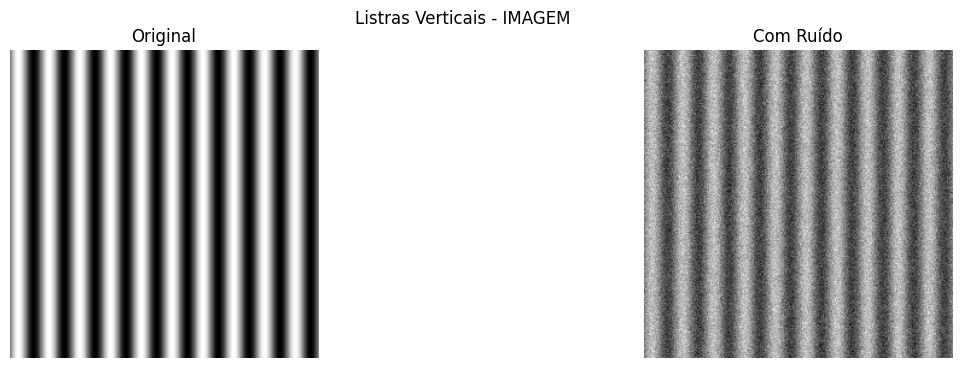

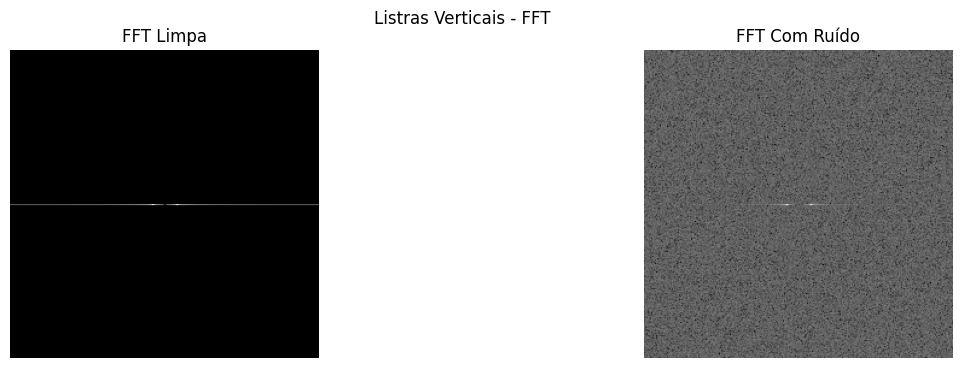

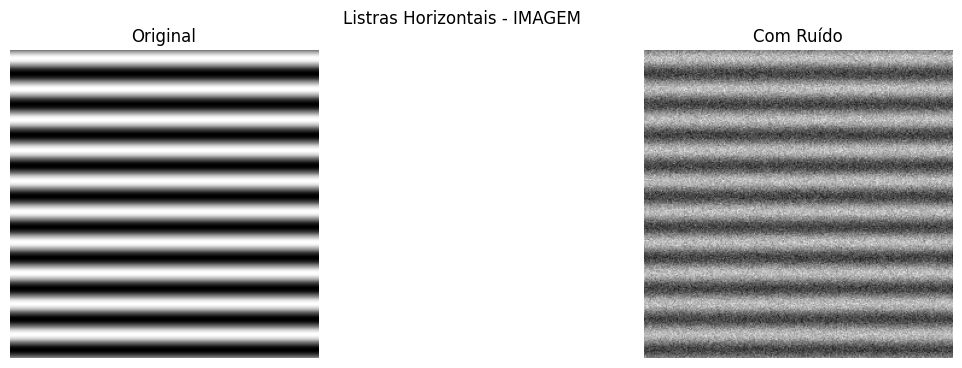

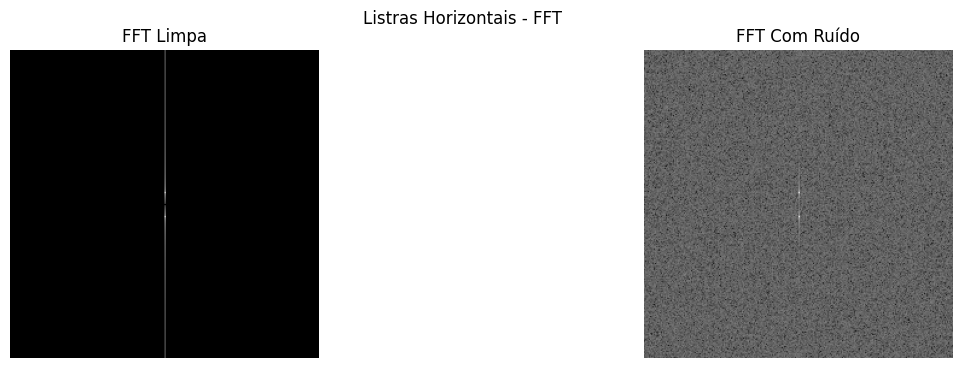

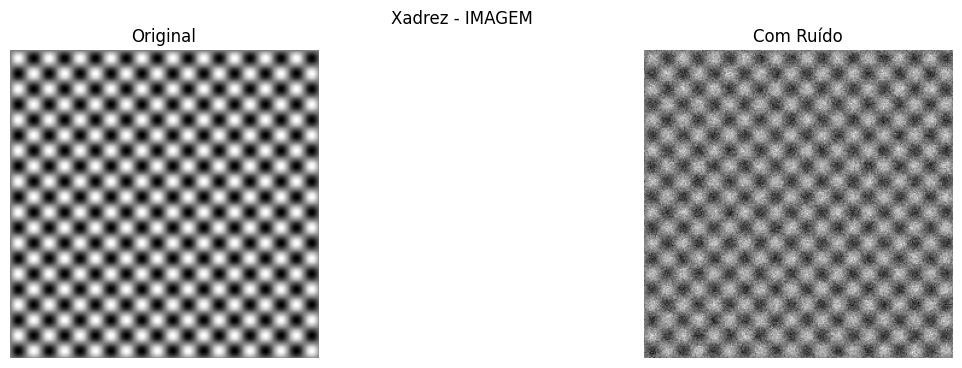

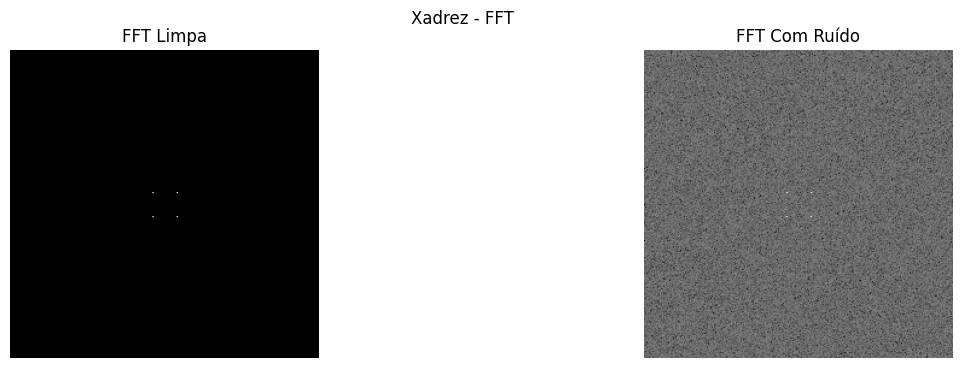

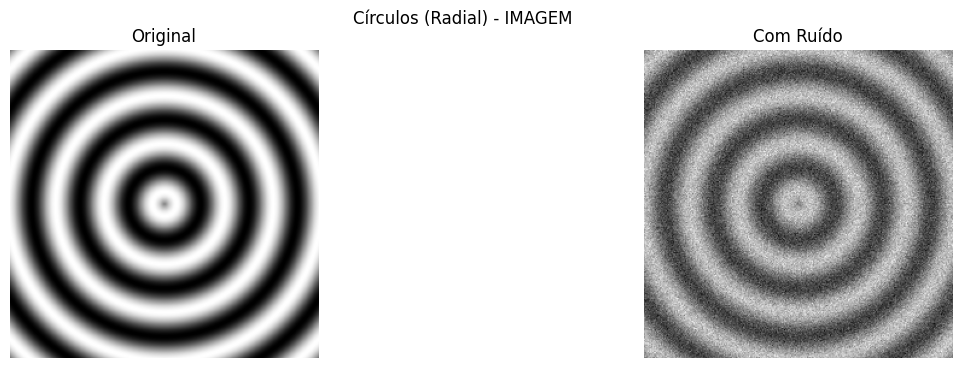

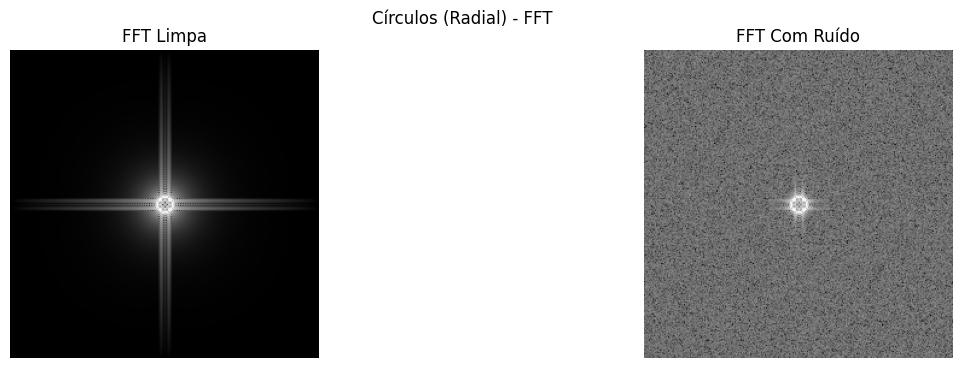

In [ ]:
# ==========================================
# 📦 IMPORTS
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 🔬 FUNÇÃO FFT
# ==========================================
def compute_fft(img):
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)
    magnitude = np.log1p(np.abs(F_shift))
    return magnitude

# ==========================================
# 🎨 FUNÇÃO PARA MOSTRAR IMAGENS
# ==========================================
def show_images(title, images):
    n = len(images)
    plt.figure(figsize=(15, 4))
    for i, (img, name) in enumerate(images):
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(name)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# ==========================================
# 🔊 ADICIONAR RUÍDO
# ==========================================
def add_noise(img, noise_level=0.3):
    noise = np.random.normal(0, noise_level, img.shape)
    return img + noise

# ==========================================
# 1. LISTRAS VERTICAIS
# ==========================================
def vertical_stripes(size=256, freq=10):
    x = np.linspace(0, 1, size)
    img = np.sin(2 * np.pi * freq * x)
    img = np.tile(img, (size, 1))
    return img

# ==========================================
# 2. LISTRAS HORIZONTAIS
# ==========================================
def horizontal_stripes(size=256, freq=10):
    y = np.linspace(0, 1, size)
    img = np.sin(2 * np.pi * freq * y)
    img = np.tile(img[:, None], (1, size))
    return img

# ==========================================
# 3. XADREZ (GRADE)
# ==========================================
def checkerboard(size=256, freq=10):
    x = np.arange(size)
    y = np.arange(size)
    X, Y = np.meshgrid(x, y)
    img = np.sin(2*np.pi*freq*X/size) * np.sin(2*np.pi*freq*Y/size)
    return img

# ==========================================
# 4. CÍRCULOS (PADRÃO RADIAL)
# ==========================================
def circular_pattern(size=256, freq=20):
    x = np.linspace(-1,1,size)
    y = np.linspace(-1,1,size)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    img = np.sin(freq * R)
    return img

# ==========================================
# FUNÇÃO PARA TESTAR PADRÕES
# ==========================================
def analyze_pattern(name, img):
    noisy = add_noise(img)

    fft_clean = compute_fft(img)
    fft_noisy = compute_fft(noisy)

    show_images(f"{name} - IMAGEM",
                [(img, "Original"), (noisy, "Com Ruído")])

    show_images(f"{name} - FFT",
                [(fft_clean, "FFT Limpa"), (fft_noisy, "FFT Com Ruído")])


# ==========================================
# EXECUÇÃO
# ==========================================

# Listras verticais
img_v = vertical_stripes()
analyze_pattern("Listras Verticais", img_v)

# Listras horizontais
img_h = horizontal_stripes()
analyze_pattern("Listras Horizontais", img_h)

# Xadrez
img_c = checkerboard()
analyze_pattern("Xadrez", img_c)

# Círculos
img_r = circular_pattern()
analyze_pattern("Círculos (Radial)", img_r)

# Interpretação dos Resultados no Domínio da Frequência

## 1. Círculos (Radial)

Na imagem de FFT limpa, observa-se uma forte concentração de energia no centro, acompanhada de uma estrutura em forma de cruz. Isso indica que a imagem possui predominância de baixas frequências (regiões suaves) e simetria radial.

A presença da cruz sugere que, apesar do padrão circular, ainda existem componentes direcionais (horizontal e vertical) influenciando a distribuição das frequências.

Na FFT com ruído, percebe-se que o espectro se torna mais disperso, com energia espalhada por toda a imagem. Isso ocorre porque o ruído adiciona componentes de alta frequência em várias direções, reduzindo a clareza do padrão original.

---

##  2. Xadrez (Grade)

Na FFT limpa, aparecem pontos bem definidos e simétricos ao redor do centro. Esses pontos representam frequências específicas nas direções horizontal e vertical, indicando um padrão periódico bidimensional.

Esse comportamento é característico de imagens com repetição regular em duas direções, como o padrão quadriculado.

Na FFT com ruído, esses pontos ainda estão presentes, porém menos visíveis devido à dispersão causada pelo ruído. O ruído introduz frequências adicionais, tornando o espectro mais “poluído”.

---

## 3. Listras Horizontais

Na FFT limpa, observa-se uma linha vertical bem definida passando pelo centro da imagem. Isso indica que a variação da imagem ocorre principalmente na direção vertical (ou seja, as listras são horizontais).

Esse padrão mostra que há uma frequência dominante em uma única direção, característica de padrões unidimensionais.

Na FFT com ruído, a linha ainda pode ser identificada, porém com menor nitidez, devido à presença de frequências aleatórias introduzidas pelo ruído.
(as listras verticais apresentão um comportamento similar porem na vertical)
---

## Conclusão Geral

* Padrões regulares geram espectros organizados e com estruturas bem definidas.
* O ruído introduz altas frequências, tornando o espectro mais disperso e dificultando a identificação dos padrões.
* A posição e a forma dos elementos no espectro indicam a direção e o tipo de variação presente na imagem original.

Essa análise permite identificar características estruturais das imagens e é fundamental para aplicações como filtragem, compressão e reconhecimento de padrões.


# Questão 1
<!-- Durante o estudo do processamento de imagens, aprendemos que uma imagem pode ser
analisada tanto no domínio espacial quanto no domínio da frequência.
Explique, com suas próprias palavras, como você entende a diferença entre esses dois domínios. Em
sua resposta, comente qual deles você considera mais intuitivo para compreender o comportamento
de uma imagem e explique o motivo da sua escolha.  -->

## o dominio espacial e aquele em que temos imgans se transformando em pixels ou seja, cada ponto da imagem representa uma intensidade de cor ou brilho. Já no domínio da frequência, a imagem é interpretada como uma combinação de padrões de variação. E como se estivessemos comparando olhar para umagem como ela é e olhar para a forma como seus dados(pixels) estao variando na imagem o que faz com que a espacial seja mais intuitiva a olho humano

# ● Questão 2
<!-- A Transformada de Fourier foi apresentada como uma ferramenta fundamental para
converter uma imagem do domínio espacial para o domínio da frequência. Descreva como você
explicaria esse conceito para um colega que ainda não estudou processamento de imagens. Procure
usar uma analogia ou exemplo simples que ajude a entender a ideia de decompor uma imagem em
frequências.  -->
## uma imagem e no geral a junção de inumeros pixels e como o celebro humano e capas de identificar e classificar padroes de maneira boa conseguimos identificar a imagem porem deixamos muita informação não perceptivel a nossos olhos para tras e por isso que usamos a transformada de Fourier ela nos permite analisar esses padrões muitos sutis

# ● Questão 3
<!-- Ao observar o espectro de frequência de uma imagem natural, normalmente encontramos
uma região central bastante brilhante. Explique o que essa região representa e discuta por que
muitas imagens do mundo real apresentam maior concentração de energia nessa região do espectro.  -->
### A região central brilhante no espectro de frequência representa as baixas frequências da imagem. Isso significa áreas onde há pouca variação de intensidade — regiões mais suaves e homogêneas.

### Isso acontece porque, na maioria das imagens naturais, predominam regiões contínuas e suaves, como paredes, céu ou superfícies. Como essas áreas mudam pouco, elas concentram muita energia nas baixas frequências. Já os detalhes (bordas, texturas) ocupam menos espaço, por isso aparecem mais afastados do centro e com menor intensidade. As imagens con concentração nitida no centro como a da circuferencia indicam uma imagem menos natural ou gerada artificialmente o que e evidenciado pela altas frequencias nos centros.
# Questão 4
<!-- Foi possível observar diferenças claras entre o espectro de uma imagem original e o espectro
da mesma imagem após a adição de ruído. Descreva quais diferenças você considera mais marcantes
entre esses espectros. Em sua resposta, explique como o ruído altera a distribuição das frequências e
qual foi a sua principal impressão ao observar esse comportamento.  -->
### ao adicionar ruido sal e pimenta na imagem isso altera a frequncia original deixando ela mais "homogenia" oque vai deixar nossa imagem no dominio da frequencia com marcações mais suaveis no centro e alta variação nas extremidades. Isso acontece porque o ruído introduz variações aleatórias na imagem, o que corresponde a altas frequências. Como resultado, o espectro perde sua estrutura mais concentrada e passa a ter componentes distribuídos de forma mais uniforme.

#● Questão 5
<!-- Filtros passa-baixa são frequentemente utilizados para suavizar imagens. Explique, com base
no que você estudou, como esse tipo de filtro atua no domínio da frequência. Em seguida, discuta
em que situações reais você acredita que esse tipo de filtragem pode ser útil.  -->
### o filtro passa baixa ele vai aplicar uma mascara sobre a imagem deixando apenas a passagem das baixas frequencias Ou seja, ele mantém as partes suaves da imagem e remove os detalhes mais bruscos.
esse tipo de filtro é útil em situações como:

Redução de ruído em imagens médicas

Suavização antes de etapas de processamento (pré-processamento)

Compressão de imagem

Remoção de pequenas imperfeições

#● Questão 6
<!-- Três tipos de filtros passa-baixa foram apresentados. Na sua opinião, qual deles parece
apresentar o comportamento mais equilibrado para aplicações práticas em imagens reais? Justifique
sua resposta discutindo as características da transição entre frequências e os possíveis efeitos visuais
na imagem filtrada.  -->
### em geral achei o filtro passa baixa bem extremo em suas transformações mais gostei mais do gaussiano pelo fato dele possuir uma transição mais suave.Diferente do filtro ideal (que corta bruscamente), o Gaussiano evita efeitos indesejados como oscilações e artefatos (efeito ringing). Já o filtro Butterworth também é interessante, mas ainda pode gerar leves distorções dependendo da ordem. O Gaussiano tende a produzir resultados mais naturais visualmente, preservando a aparência da imagem sem criar bordas artificiais.

#● Questão 7
<!-- Filtros passa-alta são utilizados para destacar detalhes e bordas em uma imagem.Explique
por que a remoção de baixas frequências pode produzir esse efeito. Em sua resposta, descreva
também como você imagina que a aparência de uma imagem mudaria após a aplicação desse tipo de
filtro.  -->
### As baixas frequências correspondem às variações suaves da imagem Quando removemos essas frequências, eliminamos essa base mais uniforme, restando principalmente as variações rápidas.Por isso, o filtro passa-alta destaca contornos. Após aplicar esse filtro, imagino a imagem com:

Menos informação de fundo,
Bordas mais evidentes,
Aparência mais “seca” ou até artificial e
Possível aumento de ruído
#● Questão 8
<!-- Durante o estudo do domínio da frequência, discutimos que diferentes estruturas da imagem
estão associadas a diferentes faixas de frequência. Com base nessa ideia, explique por que um filtro
passa-banda pode ser útil para destacar determinados padrões ou texturas em uma imagem. Cite um
exemplo de aplicação em que você acredita que esse tipo de filtro poderia ser interessante.  -->
###Um filtro passa-banda permite apenas uma faixa específica de frequências, bloqueando tanto as muito baixas quanto as muito altas. Isso é útil porque diferentes padrões da imagem estão associados a faixas específicas de frequência. Por exemplo, texturas repetitivas costumam estar em frequências intermediárias. Assim, podemos isolar essas características.Um exemplo de aplicação seria:

Identificação de padrões em tecidos ou superfícies industriais,
Análise de impressões digitais,
Detecção de padrões em imagens médicas

#● Questão 9
<!-- Imagine que você recebeu uma imagem muito degradada por ruído. Descreva qual
estratégia de filtragem você tentaria primeiro para melhorar essa imagem. Explique por que escolheu
esse tipo de filtro e quais seriam suas expectativas em relação ao resultado final.  -->
### Eu começaria utilizando um filtro passa-baixa, como o Gaussiano. Escolhi esse filtro porque o ruído geralmente está associado a altas frequências. Ao reduzir essas frequências, conseguimos suavizar a imagem e diminuir o impacto do ruído Minhas expectativas seriam:
Redução significativa do ruído

Perda de alguns detalhes finos

Imagem mais suave e limpa

Depois disso, dependendo do resultado, eu poderia aplicar técnicas adicionais, como filtros adaptativos ou até realce de bordas.

#● Questão 10
<!-- Após estudar a análise de imagens no domínio da frequência, reflita sobre a seguinte
questão: Qual foi o aspecto desse conteúdo que mais chamou sua atenção ou que você considerou
mais interessante durante o estudo? Explique por que esse ponto foi marcante para você e como ele
contribuiu para sua compreensão do processamento digital de imagem.
 -->
### oque mais mi chamou atenção foi saber que existia uma nova forma de visualizar imagens e tambem uma nova forma de processalas de uma maneira que nunca imaginei as  aplicabilidades e capacidade de trabalhar com imagens almentou muito agora posso trabalhar problemas que tive em outros trabalho sobre uma nova prespectiva e com uma visao e analise completamente diferente
